<!-- ![RF_Explained](InputFigures/Picture2.jpg) -->

<div style="background-color: #f5f5f5; border: 4px solid black; border-radius: 10px; padding: 30px 20px; margin: 10px 0px; text-align: center;">
    
    
<h1 style="margin: 0px 0px 10px 0px;">🌊 Hydrological Diversity in Great Britain</h1>
    
<h3 style="margin: 0px; color: #555555; font-weight: normal; font-style: italic;">
Using CAMELS-GB-v2 to explore, explain, and predict catchment behaviour
</h3>

---
    
<!-- ![RF_Explained](InputFigures/Picture2.jpg)         -->
    
<!-- --- -->
    
## Agenda:
    
---    
    
<!-- The workshop will cover the following areas:   -->

    
<div style="text-align: left; margin-top: 20px;">
    
    
<!-- ## Why study hydrological diversity?    
    
- Great Britain is very hydrologically diverse, in terms of:
    - How water enters the catchment (precipitation inputs)
    - How water is stored and released in the catchment 
        -  In areas with steep sided catchments and impermeable soils heavy rainfall leads to flashy response
        - Elsewhere, where catchments have shallow gradients and Chalk aquifers providing high storage capacity, responses to rainfall are much slower
- Understanding this diversity is crucial for accurately predicting how catchments will respond to rainfall and hydrological response and flood risk

--- -->
    

<!-- | | Objective |
|---|---|
| 🗺️ **Explore** | Navigate and visualise the CAMELS-GB catchment attribute and boundary datasets |
| 📊 **Describe** | Extract and interpret event-scale behaviour from CAMELS-GB hourly time series |
| 🔍 **Explain** | Use CAMELS-GB catchment attributes to identify the drivers of hydrological diversity |
| 🤖 **Predict** | Build and evaluate a Random Forest model trained on CAMELS-GB attribute data | -->

    
<div style="display:flex; gap:12px; font-family:sans-serif;">
  <div style="background:#dbeafe; border:1px solid #93c5fd; border-radius:8px; padding:16px; flex:1;">
    <strong>🗺️ Explore</strong><br>Navigate &amp; visualise CAMELS-GB catchment attributes &amp; boundaries
  </div>
  <div style="font-size:1.4em; align-self:center;">→</div>
  <div style="background:#dcfce7; border:1px solid #86efac; border-radius:8px; padding:16px; flex:1;">
    <strong>📊 Describe</strong><br>Extract &amp; interpret event-scale behaviour from hourly time series
  </div>
  <div style="font-size:1.4em; align-self:center;">→</div>
  <div style="background:#fef9c3; border:1px solid #fde047; border-radius:8px; padding:16px; flex:1;">
    <strong>🔍 Explain</strong><br>Identify drivers of hydrological diversity using catchment attributes
  </div>
  <div style="font-size:1.4em; align-self:center;">→</div>
  <div style="background:#fce7f3; border:1px solid #f9a8d4; border-radius:8px; padding:16px; flex:1;">
    <strong>🤖 Predict</strong><br>Build &amp; evaluate a Random Forest model on CAMELS-GB data
  </div>
</div>    
   
--- 
    
## Introduction: The CAMELS-GB-v2 Dataset

This workshop uses **CAMELS-GB-v2** — *Catchment Attributes and MEteorology for 
Large-sample Studies, Great Britain* — a comprehensive dataset covering **671 
catchments** across Great Britain.

Data is available here: https://catalogue.ceh.ac.uk/documents/8344e4f3-d2ea-44f5-8afa-86d2987543a9  
Further information on the dataset is here: https://essd.copernicus.org/preprints/essd-2025-608/essd-2025-608.pdf

---
    
### What does it contain?

| Data type | Coverage | Variables included |
|---|---|---|
| 🗺️ **Catchment boundaries** | 671 catchments | Polygons in British National Grid |
| 🏔️ **Catchment attributes** | Static summaries | Topography, climate, hydrology, soils, land cover, hydrogeology |
| 🌧️ **Meteorological time series** | 1970–2015, daily & hourly | Rainfall, PET, temperature, radiation, humidity |
| 💧 **River flow records** | 1970–2015, daily & hourly | Discharge, specific runoff |
    
### Why is this useful?
    
---


CAMELS-GB is an example of a **large-sample hydrological dataset**, allowing hydrological behaviour to be examined across hundreds of catchment simultaneously. This is invaluable for hydrological process undertanding and modelling, allowing us to: 


- Identify **patterns** in how catchments behave across different landscapes and climates
- Test whether **general relationships** hold across a wide range of conditions
- Build **predictive models** that can be applied to ungauged locations

---
    


    
    
---

## Research Questions

By the end of this workshop, we will have worked towards answering:

> 1. How does catchment behaviour vary **spatially** across Great Britain?
> 2. What are the **controls** on that variability — climate, soils, topography, geology?
> 3. Can we **predict** catchment behaviour from observable attributes alone?


</div>

<div style="background-color: #f5f5f5; border-left: 5px solid #888888; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

<h3 style="margin: 0px 0px 5px 0px; color: #555555;">⚙️ 0. Setup</h3>
<p style="margin: 0px; color: #555555; font-style: italic;">
Run this cell first — it imports the packages and sets the data path needed throughout the notebook.
</p>

</div>

In [1]:
# import gdown
# import os

# os.makedirs("Data", exist_ok=True)

# url = "https://drive.google.com/drive/folders/1Qr35B6aKoDg0M-ktn4dMdsbcmM3E0L5e"
# gdown.download(url, "Data/erc.csv", quiet=True)

# folder_url = "https://drive.google.com/drive/folders/11keX4QvXSeiobHR1Af1T4dfB7erZdkmq"
# gdown.download_folder(folder_url,output="Data/Catchment_Attributes",  quiet=True, use_cookies=False)

# folder_url = "https://drive.google.com/drive/folders/1LW3uO-__KckP_aELWCOYIEuFxkz-J_qI"
# gdown.download_folder(folder_url,output="Data/Catchment_Boundaries",  quiet=True, use_cookies=False)

# url = "https://drive.google.com/drive/folders/1Qr35B6aKoDg0M-ktn4dMdsbcmM3E0L5e"
# gdown.download(url, "Data/CAMELS_GB_v2_hydromet_hourly_timeseries_21006_19901001-20221001.csv", quiet=True)

# url = "https://drive.google.com/drive/folders/1Qr35B6aKoDg0M-ktn4dMdsbcmM3E0L5e"
# gdown.download(url, "IntroSlides.pdf", quiet=True)

In [2]:
import pandas as pd
import os
import geopandas as gpd
import matplotlib.pyplot as plt
import numpy as np
from shapely.geometry import Point
import contextily as ctx
from matplotlib.colors import PowerNorm

home_dir = "/scratch/hydro4/shared_data/uk_catchment_data/camels_gb_v2/"
# home_dir = "Data/"

<div style="background-color: #2196F3; color: white; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;">
<h1 style="color: white; margin: 0px;">🗺️ 1. EXPLORE</h1>
<p style="margin: 5px 0px 0px 0px;">Spatial patterns in hydrological diversity</p>
 
</div>

We'll begin this session by taking some time to **explore the CAMELS-GB-v2 dataset** and what we can learn from it about hydrological diversity. 

In this section, we will:
1. Load the CAMELS-GB catchment attribute datasets
2. Visualise how key variables vary spatially across Great Britain
3. Begin to think about what might be driving those patterns

    
### What does it contain?

| Data type | Coverage | Variables included |
|---|---|---|
| 🗺️ **Catchment boundaries** | 671 catchments | Polygons in British National Grid |
| 🏔️ **Catchment attributes** | Static summaries | Topography, climate, hydrology, soils, land cover, hydrogeology |
| 🌧️ **Meteorological time series** | 1970–2015, daily & hourly | Rainfall, PET, temperature, radiation, humidity |
| 💧 **River flow records** | 1970–2015, daily & hourly | Discharge, specific runoff |

---

## 1.1 Accessing catchment level summary data

Firstly, let's use  `geopandas`  to read in a shapefile containing the **Catchment Boundaries**: 

---

In [47]:
catchment_boundaries = gpd.read_file(home_dir + "Catchment_Boundaries/CAMELS_GB_v2_catchment_boundaries.shp")
catchment_boundaries.rename(columns={'ID':'gauge_id'}, inplace=True)

<Axes: >

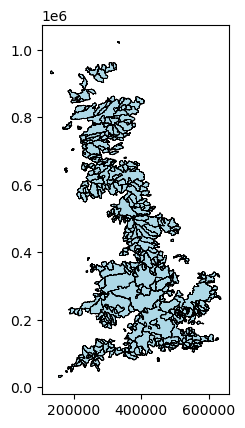

In [48]:
catchment_boundaries.plot(edgecolor='black', linewidth=0.5, color='lightblue')

---

<!-- **Your task**   -->
And then, use  `pandas` to load **Catchment Attribute** data: csv files containing catchment level summaries of:  
- Climatic attributes
- Topographic attributes
- Hydrogeological attributes  
- Landcover attributes  
- Soil attributes  
- Hydrological signatures  

For explanations of the variables see _Table 5_ in this paper: https://essd.copernicus.org/preprints/essd-2025-608/essd-2025-608.pdf

---

In [49]:
climatic_attributes = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_climatic_attributes.csv")
climatic_attributes.head()

,gauge_id,p_mean,pet_mean,aridity,p_seasonality,frac_snow,high_prec_freq,high_prec_dur,high_prec_timing,low_prec_freq,low_prec_dur,low_prec_timing
0,10002,2.35,1.33,0.56,-0.06,0.03,13.75,1.16,son,205.90,3.13,jja
1,10003,2.37,1.35,0.57,-0.02,0.04,13.62,1.17,son,208.21,3.20,mam
2,1001,2.56,1.21,0.47,-0.15,0.04,10.58,1.11,son,181.56,2.92,jja
3,101002,2.37,1.81,0.76,-0.22,0.00,20.67,1.17,son,243.73,4.44,jja
4,101005,2.28,1.80,0.79,-0.20,0.00,20.60,1.19,son,245.58,4.51,jja


In [50]:
hydrologic_attributes = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_hydrologic_attributes.csv")
climatic_attributes = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_climatic_attributes.csv")
topography = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_topographic_attributes.csv")
hydrogeology = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_hydrogeology_attributes.csv")
landcover = pd.read_csv(home_dir + "Catchment_Attributes/CAMELS_GB_v2_landcover_attributes.csv")
soil = pd.read_csv(home_dir + 'Catchment_Attributes/CAMELS_GB_v2_soil_attributes.csv')

---

 We can then use the shared `gauge_id` column to join (or merge) all these datasets together, so we have all of the variables together in one place. 

---

In [51]:
catchment_attributes = (topography
          .merge(climatic_attributes, on="gauge_id", how="left")
          .merge(hydrogeology, on="gauge_id", how="left")
          .merge(landcover, on="gauge_id", how="left")
          .merge(soil, on="gauge_id", how="left")
          .merge(hydrologic_attributes, on="gauge_id", how="left")
          .merge(catchment_boundaries[['gauge_id', 'geometry']], on="gauge_id", how="left"))

In [53]:
# catchment_attributes.head()

---

### 1.2 Plotting catchment summary data spatially
Now we have all the catchment attribute data in one place, we can make some maps which visualise how the catchment attributes vary spatially.


> 💡 Spatial visualisation is often the fastest way to spot structure in a 
> large dataset — patterns that would be invisible in a table of numbers become 
> immediately obvious on a map.

For this, we can use `geopandas` to convert our dataframe into a geodataframe which allows us to more easily work with location data. This uses the `geometry` column which was part of the catchment_boundaries file


---

In [54]:
# Create geodataframe
catchment_attributes_gdf = gpd.GeoDataFrame(catchment_attributes, crs="EPSG:27700", geometry=catchment_attributes['geometry'])
# Convert the coordinate reference system (CRS), so as to work with basemaps
catchment_attributes_gdf = catchment_attributes_gdf.to_crs(epsg=3857)

In [56]:
# catchment_attributes_gdf.plot('q_mean')

---

Using this `geodataframe` we can then easily produce a map using `matplotlib` plotting functionalities.


Below, we create two maps side by side showing each catchment's mean daily precipitation and mean daily runoff.

---

In [57]:
# climatic_attributes.columns

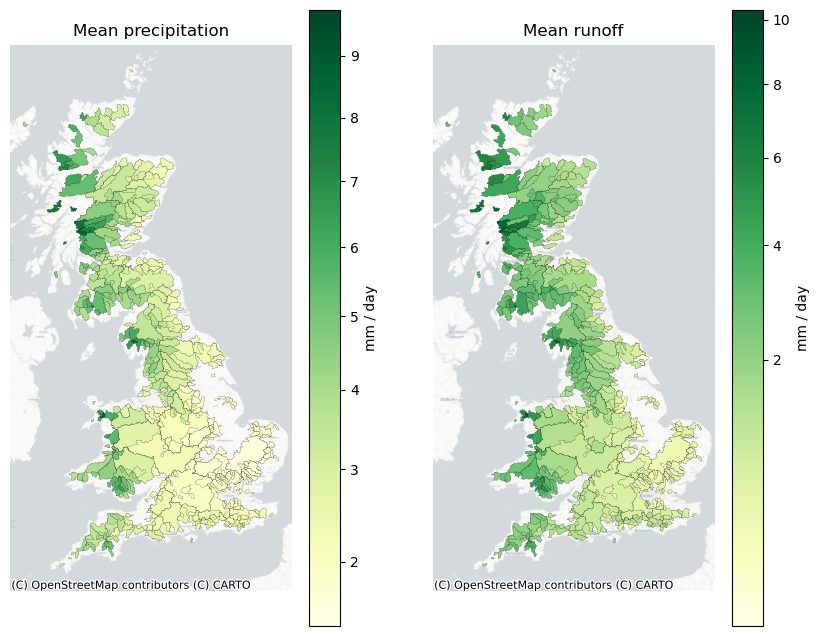

In [59]:
# Create a figure and axes object(s), which we will then plot onto
fig,axs=plt.subplots(ncols=2, figsize=(10,8))
catchment_attributes_gdf.plot('p_mean', ax=axs[0], legend=True,  cmap='YlGn', edgecolor='black', linewidth=0.1,
                     norm=PowerNorm(gamma=0.8),
            legend_kwds={"label": "mm / day", "orientation": "vertical"})
axs[0].axis('off')
axs[0].set_title("Mean precipitation")
ctx.add_basemap(axs[0], source=ctx.providers.CartoDB.Positron, zoom=8)

catchment_attributes_gdf.plot('q_mean', ax=axs[1], legend=True,  cmap='YlGn', edgecolor='black', linewidth=0.1,
                     norm=PowerNorm(gamma=0.5),
            legend_kwds={"label": "mm / day", "orientation": "vertical"})
axs[1].axis('off')
axs[1].set_title("Mean runoff")
ctx.add_basemap(axs[1], source=ctx.providers.CartoDB.Positron)

In [61]:
# plt.scatter(catchment_attributes_gdf['p_mean'], catchment_attributes_gdf['q_mean'])

<div style="background-color: #f0faf0; border: 1px solid #4CAF50; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Task 1: Coding challenge: explore spatial patterns

### **Your task**  
Use the code above as a template to investigate spatial patterns in other catchment attributes across Great Britain.

➤ Create a map showing the spatial patterns in two (or more) variables and:
- Add a clear, descriptive title  
- Choose a variable that shows an interesting pattern  
- Choose an appropriate colour scale
- Share your plot in the chat, describe what it shows, think about why  

---

### 🤔 Think about it
- Which variables might show the strongest spatial gradients?  
- Think about the ways in which changing how you present the data changes how you interpert what you see? e.g., does changing the colour map affect what patterns you notice?  

---

<details>
<summary>💡 Hints (click to expand)</summary>

- Use `list(catchment_attributes_gdf.columns)` to explore available variables  
- See Table 5 here for variable descriptions:  
  https://essd.copernicus.org/preprints/essd-2025-608/essd-2025-608.pdf  
- Try different colour maps like `Blues`, `YlGn`  (for more options see: https://matplotlib.org/stable/users/explain/colors/colormaps.html)
- Experiment with `PowerNorm(gamma=0.5)`. What does this do? Does it help make spatial differences clearer or more confusing?  

</details>


</div>

<div style="background-color: #CEC2EB; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Bonus challenge

</div>

<!-- <div style="background-color: #f0faf0; border: 1px solid #4CAF50; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

### ✅ Key takeaways from this section
- ERC varies substantially across GB catchments
- Climate explains ~46% of that variation in a linear model
- A Random Forest captures additional non-linear structure

</div> -->

<div style="background-color: #2196F3; color: white; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;">
<h1 style="color: white; margin: 0px;">🗺️ 2. DESCRIBE </h1>
<p style="margin: 5px 0px 0px 0px;"> What else can the data in CAMELS tell us? </p>
</div>

In the previous section we used the **catchment attributes** data to explore spatial patterns in descriptors of mean catchment hydrological behaviour - for instance we plotted the **mean daily runoff** and the **mean daily precipitation**. 

In this section, we will demonstrate how another dataset included in CAMELS-GB, the **hydro-meteorological time-series**, can be used to gain further insight into how catchments respond to individual rainfall events. 
> 💧 This is important because two catchments may have the same mean runoff behaviour, but actually respond to rainfall in completely different ways. For instance, one might produce a slow, steady response over days, while another might peak within hours and then drain away just as quickly. 

<!-- This provides a useful summary of how much water a catchment produces on average. However, it doesn't give us much insight into how a catchment actually *behaves* during a given rainfall event. -->

In this section, we will:
1. Explore the timeseries data for one rainfall event for a single catchment
2. Introduce a metric, the **Event Runoff Coefficient (ERC)**, which captures responsivness
3. Look at spatial patterns in the ERC over Great Britain


<!-- ### What does time series data add?

| Mean runoff tells us... | Time series data tells us... |
|---|---|
| How much water a catchment produces on average | How *quickly* rainfall becomes runoff |
| Long-term climatic water balance | How catchments behave during individual storms |
| Useful for water resource planning | Essential for flood forecasting and risk | -->

---

## 2.1 An example for one catchment of timeseries summary data
> Firstly, let's select a catchment and check where it is located:

---

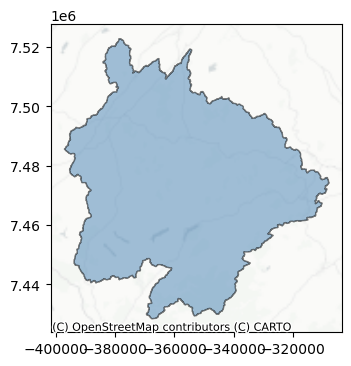

In [20]:
# Select a catchment id
catchment_id = 21006 # 15006

# Filter catchment boundaries so we only have this one
one_gauge = catchment_boundaries[catchment_boundaries['gauge_id'] == catchment_id]

# Reproject to Web Mercator (EPSG:3857) — required by contextily
one_gauge = one_gauge.to_crs(epsg=3857)

# Create a plot
fig, ax = plt.subplots(ncols=1, figsize=(7, 4))
one_gauge.plot(ax=ax, alpha=0.5, edgecolor='black', color='steelblue')

# Add basemap — contextily needs Web Mercator
ctx.add_basemap(ax, source=ctx.providers.CartoDB.Positron, zoom=8)

##### Increase the bounds of the plot so it's possible to see where the catchment is
# x_min, y_min, x_max, y_max = one_gauge.total_bounds
# buffer = 50000  # metres
# ax.set_xlim(x_min - buffer, x_max + buffer)
# ax.set_ylim(y_min - buffer, y_max + buffer);
# ax.axis('off');

---

> **Next**: we'll read in timeseries data for this catchment and then select 72 (or 3 days) worth of the data.  
The timeseries data includes both precipitation and discharge recorded in the catchment.  

---

In [26]:
# read in time series data
ts = pd.read_csv(home_dir + f'Catchment_Timeseries/Hydro-Meteorological/Hourly/CAMELS_GB_v2_hydromet_hourly_timeseries_{catchment_id}_19901001-20221001.csv')
# check which variables are present
ts.head()

# Select one storm event from the timeseries
ts_event = ts.iloc[100:172]  # first 2 days hourly

---

> **Finally:** we'll construct a plot showing the total precipitation in each timestep as blue bars, and the concurrently recorded runoff as an orange line

---

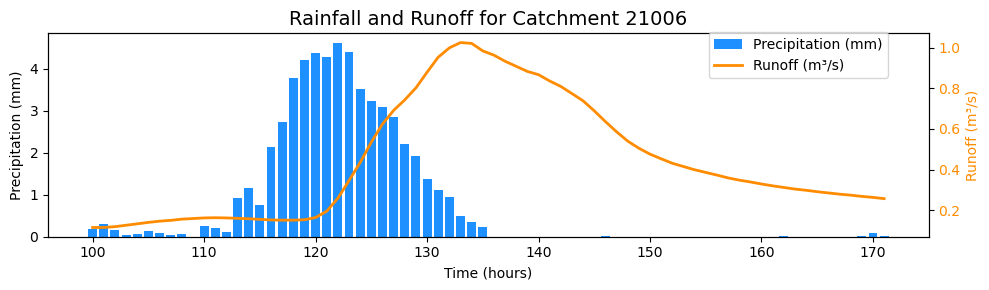

In [27]:
fig, ax1 = plt.subplots(figsize=(10,3))

# Plot precipitation as bars
ax1.bar(ts_event.index, ts_event['precipitation_cehgear'], color='dodgerblue', label='Precipitation (mm)')
ax1.set_ylabel('Precipitation (mm)', color='black')
ax1.tick_params(axis='y', labelcolor='black')

# Plot runoff as line
ax2 = ax1.twinx()
ax2.plot(ts_event.index, ts_event['discharge_spec'], color='darkorange', linewidth=2, label='Runoff (m³/s)')
ax2.set_ylabel('Runoff (m³/s)', color='darkorange')
ax2.tick_params(axis='y', labelcolor='darkorange')

# Title and labels
plt.title(f"Rainfall and Runoff for Catchment {catchment_id}", fontsize=14)
ax1.set_xlabel("Time (hours)")

# Optional: add legend
fig.legend(loc='upper right', bbox_to_anchor=(0.9, 0.9))

plt.tight_layout()
plt.show()

---

## 2.2 Introducing the Event Runoff Coefficient (ERC)

The figure plotted above shows that: while runoff tracks precipitation, there is a clear lag between peak rainfall and peak runoff. It also appears that the total volume of runoff may be less than the total precipitation, suggesting that not all rainfall reaches the river. 

For any rainfall event, we can use these two values to calculate a metric which describes how much rainfall becomes runoff, called the Event Runoff Coefficient (ERC):

$$
\text{ERC} = \frac{\text{Direct runoff from an event}}{\text{Rainfall from the same event}}
$$

<!-- reflecting storage, infiltration, and antecedent soil moisture.   -->
- High ERC → most rainfall becomes runoff (catchment is more responsive)  
- Low ERC → much rainfall is absorbed or stored (catchment is buffered)  

In [Zheng et al. (2022)](https://agupubs.onlinelibrary.wiley.com/doi/full/10.1029/2022WR033227) the mean ERC is calculated for all catchments in GB, using CAMELS-GB data. This provides a very useful dataset through which to: 

- Understand **catchment response to rainfall** beyond averages  
- Compare **different catchments’ behaviour** under similar rainfall conditions  
- Support **flood design, hydrological modelling, and classification** of catchments  

<!-- But this is just one catchment — across GB, the size of that lag, the shape of the runoff response, and the fraction of precipitation that becomes runoff will vary enormously depending on the catchment's soils, geology, and topography.

So, how do we quantify that variation systematically across hundreds of catchments? -->

In the exercises below, we will explore how catchment attributes relate to **ERC**, helping us connect static attributes to dynamic behaviour.

> ⚠️ **Note:** ERC describes *how much* rainfall becomes runoff, not *how quickly* 
> the catchment responds. A high ERC catchment is not necessarily flashy — 
> timing and volume are related but distinct aspects of catchment behaviour.

---

In [35]:
# Read in the data
erc = pd.read_csv('../Data/erc.csv')
# erc = pd.read_csv('Data/erc.csv')
# rename the ID column to match the catchment attribute data
erc.rename(columns={'Catchment ID': 'gauge_id', 'Mean':'Mean_ERC'}, inplace=True)

In [36]:
# Join with the catchment attribute data (pre conversion to GDF)
catchment_attributes_with_erc = erc.merge(catchment_attributes, on=['gauge_id'], how='left')
# Convert to geodataframe and reproject
catchment_attributes_with_erc_gdf = gpd.GeoDataFrame(catchment_attributes_with_erc, crs="EPSG:27700", geometry=catchment_attributes_with_erc['geometry'])
catchment_attributes_with_erc_gdf = catchment_attributes_with_erc_gdf.to_crs(epsg=3857)

---

## 2.3. Comparison between mean runoff and the event runoff coefficient

Using similar code to before, we can plot side-by-side the spatial patterns in the ERC and in the mean runoff.  
This allows us to examine whether the spatial patterns are similar. 


---

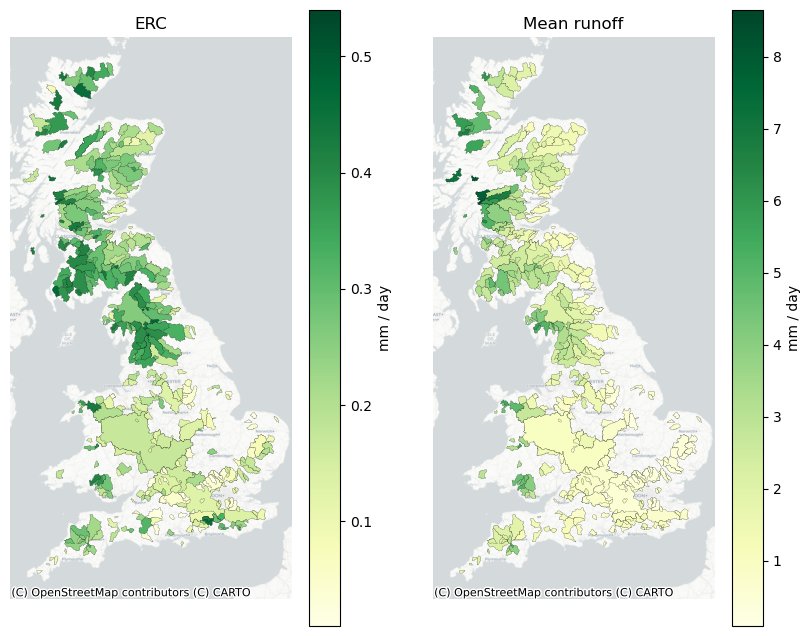

In [37]:
fig,axs=plt.subplots(ncols=2, figsize=(10,8))
catchment_attributes_with_erc_gdf.plot('Mean_ERC', ax=axs[0], markersize=30, legend=True,  cmap='YlGn', edgecolor='black', linewidth=0.1,
#                      norm=PowerNorm(gamma=0.5),
            legend_kwds={"label": "mm / day", "orientation": "vertical"})
axs[0].axis('off')
axs[0].set_title("ERC")
ctx.add_basemap(axs[0], source=ctx.providers.CartoDB.Positron)

catchment_attributes_with_erc_gdf.plot('q_mean', ax=axs[1], markersize=30, legend=True,  cmap='YlGn', edgecolor='black', linewidth=0.1,
#                      norm=PowerNorm(gamma=0.5),
            legend_kwds={"label": "mm / day", "orientation": "vertical"})
axs[1].axis('off')
axs[1].set_title("Mean runoff")
ctx.add_basemap(axs[1], source=ctx.providers.CartoDB.Positron)

<div style="background-color: #f0faf0; border: 1px solid #4CAF50; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## **Task 2:**
    
    
### **Your task**  
Spatial patterns are different between the mean runoff and the ERC. Think about why this might this be and what is likely to be driving behaviour for each.

➤ Write your ideas in the chat
    
      
<!--     
<details>
<summary>💡 Possible answers (click to expand)</summary>

- Low mean runoff suggests a fairly dry climate, however, when rainfall events do happen, the catchment may still respond quickly ???
- THINK ABOUT ANSWERS TO THIS MORE
</details> -->

    
<div/>

<div style="background-color: #2196F3; color: white; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;">
<h1 style="color: white; margin: 0px;">🗺️ 3. EXPLAIN </h1>
<p style="margin: 5px 0px 0px 0px;">What drives hydrological diversity</p>
</div>

In Part 1 and 2, we explored how catchment attributes vary across Great Britain, building up a picture of spatial patterns in climate, landscape, and hydrology. We looked at both mean behaviour and also how catchments respond to rainfall over shorter timescales. 

This helped us to begin to consider the question of:

> **Why do catchments behave differently?**

In this section, we will move beyond describing patterns to **explaining them**, by:

1. Exploring pairwise relationships between the ERC and other catchment attribute variables

---

### From patterns to processes

Hydrological behaviour varies between catchments due to a combination of:

- **Climate inputs** (e.g. rainfall amount, seasonality, snow)
- **Catchment characteristics** (e.g. soils, topography, land cover, storage)

These factors interact to control how rainfall is:
- Stored  
- Transmitted  
- Released as runoff  

---


###  Why this matters

Understanding the drivers of hydrological behaviour is essential because:

- It helps us **interpret observed differences** between catchments  
- It allows us to **predict behaviour in ungauged locations**  
- It underpins hydrological modelling and flood/drought assessment  

➤ This means that:

> If we understand *why* catchments behave differently, we can begin to **model and predict** that behaviour.

<!-- 
### 🤔 Think about it

- Which catchment characteristics do you expect to have the strongest influence on runoff behaviour?  
- Do you think climate or landscape is more important—or does it depend on the context?
 -->

In the following exercises, we’ll begin to explore these relationships using the CAMELS-GB dataset.
    


---
## 3.1 Which variables might explain spatial variation in event runoff coefficient (ERC)? 

We've seen that ERC varies spatially across GB. But which catchment properties might explain that variation? 

A sensible first step is to look at simple pairwise relationships — does ERC tend to be higher in wetter catchments? In steeper ones? In those with more woodland?

Below, we calculate the pair-wise correlation betwen the climatic variables and the ERC:

---

In [38]:
# Specify the names of the climate variable columns, removing the gauge_id and two variables which are not continuous
climatic_columns =  list(climatic_attributes.columns)
cols_to_remove = ['gauge_id', 'high_prec_timing', 'low_prec_timing']
climatic_columns = [x for x in climatic_columns if x not in cols_to_remove]

In [41]:
# Compute correlations with the target (Mean ERC)
corr_with_target = climatic_attributes[climatic_columns].corrwith(catchment_attributes_with_erc_gdf['Mean_ERC' ])

# Display as a sorted Series (absolute values)
corr_with_target.abs().sort_values(ascending=False)

# # Display as a sorted Series (not absolute)
corr_with_target.sort_values(ascending=False)

p_mean            0.248353
high_prec_dur     0.086747
frac_snow         0.045858
high_prec_freq   -0.072115
low_prec_dur     -0.104488
pet_mean         -0.115289
low_prec_freq    -0.215524
aridity          -0.290155
p_seasonality    -0.383874
dtype: float64

---

This shows us that the strongest relationship is a negative relationship with precipitation seasonality. 
> Precipitation seasonality tells us *when* in the year rain tends to fall.  
A negative value suggests that the rainfall is concentrated in winter, whereas a positive value shows that it is more concentrated in summer

---

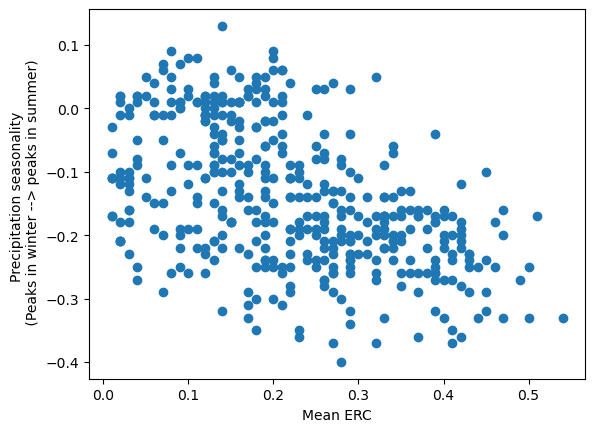

In [45]:
# We can also visualise the relationship as a scatter plot 
plt.scatter(catchment_attributes_with_erc['Mean_ERC'], catchment_attributes_with_erc['p_seasonality'])
plt.xlabel("Mean ERC")
plt.ylabel("Precipitation seasonality \n (Peaks in winter --> peaks in summer)");

<div style="background-color: #f0faf0; border: 1px solid #4CAF50; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

### **Task 3 (5-10 minutes)**:

> **Part 1**: The table above shows correlations with climatic variables. Use the tables in the CAMELS-GB paper linked at the top to understand more about the most correlated climatic variables. Why might `p_seasonality` be linked to ERC? 
    
   
> **Part 2**: Run the same analysis for one of the other attribute sets (e.g., soil, landcover, hydrogeology or topography). Find which variable has the strongest overall relationship with ERC. Plot a scatter plot of the ERC against that variable. Check the variable definition and describe the relationships:
 (e.g., as the ... increases the ERC decreases... ). Think about the reasons for that relationship.
    
Once you've finished, please post your answers in the chat.    
    
---
    
<details>
<summary>💡 Hints (click to expand) </summary>

- Get the columns for the attributes in the same way as we did for the climatic variables, e.g.,:
```python
topographic_columns =  list(topography.columns)
soil_columns =  list(soil_attributes.columns)
```
- Think about which columns you might need to remove (anything that's not a number)

    
- BONUS: Try visualising the correlations:   
    
```    
corr_sorted = corr_with_target.sort_values()

plt.figure(figsize=(4, 5))
plt.barh(corr_sorted.index, corr_sorted.values, color=['indianred' if x < 0 else 'royalblue' for x in corr_sorted])

plt.axvline(0)
plt.xlabel('Correlation with Mean ERC')
plt.title('Correlation of Climatic Attributes with Mean ERC')

plt.tight_layout()
plt.show()    
```
</details>    
    
</div>

<div style="background-color: ORANGE; border: 1px solid ORANGE; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## 🍵 **BREAK** 🍵
    
Take 10 minutes to take a break, walk around, get a cup of tea.
    
Please return by XX:XX 
    
    


<div style="background-color: #2196F3; color: white; padding: 15px 20px; border-radius: 5px; margin: 10px 0px;">
<h1 style="color: white; margin: 0px;">🗺️ 4. PREDICT </h1>
<p style="margin: 5px 0px 0px 0px;">Building a machine learning model</p>
</div>

In the previous sections, we **described** and **explained** spatial patterns in 
catchment behaviour. We found that ERC varies substantially across GB, driven by 
differences in climate, soils, and landscape.

Going beyond this, we want to now try to **predict** ERC values based on the other attribute data. 

---

### Why predict?

In hydrology, we frequently need to estimate runoff behaviour in locations with 
**no flow measurements** — called **ungauged catchments**.

These are extremely common. The majority of rivers worldwide have little or no 
observational record, yet decisions about flood risk, water resources, and 
infrastructure still need to be made for these locations.

> 💡 If we can learn the relationship between **catchment attributes** and **hydrological 
> behaviour**, we can predict behaviour for any location where we have that attribute data - even without a flow gauge.

<!-- This is the core idea behind **regionalisation** in hydrology. -->

---
<!-- 
### 🤔 Think about it

Before building the model, consider:
- Which catchment attributes do you expect to be the most useful predictors?
- Do you think a simple or complex model will perform better — and why?

---
 -->
 
### What we'll build

We'll build both a simple linear model and a more complex random forest model.  We'll compare their performance and explore what each model reveals about the most important drivers of catchment behaviour.

| Model | Type | Why? |
|---|---|---|
| **Linear Regression** | Simple, interpretable baseline | Fast to fit; easy to understand |
| **Random Forest** | Non-linear machine learning | Captures complex interactions between predictors |

---

<div style="background-color: #f5f5f5; border-left: 5px solid #888888; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

<p style="margin: 0px; color: #555555; font-style: italic;">
<h3 style="margin: 0px 0px 5px 0px; color: #555555;">⚙️ 4.0. Setup</h3>
We need to import some more specific packages that support machine learning operations
</p>

</div>

In [62]:
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split

---

## 4.1 From correlations to a simple model

Correlations tell us about individual relationships, but catchment behaviour is shaped by multiple factors simultaneously. 

A linear regression lets us combine several predictors and ask: how well can we explain ERC from all the climate variables together?

We'll start by building a linear model to predict the Mean ERC based on the catchment's climatic attributes.

---

Climate-only model
R2: 0.5089480359433305
RMSE: 0.0848198911078334


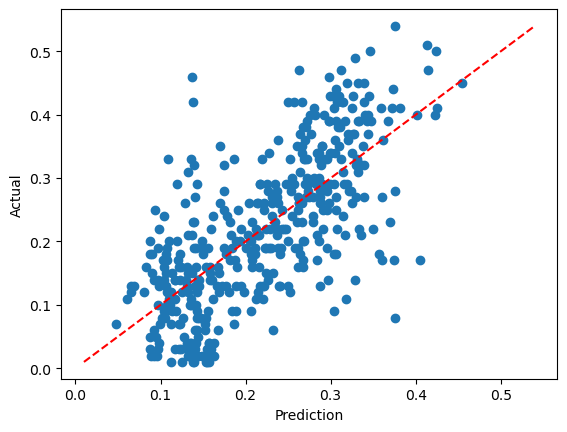

In [64]:
# Define the variables we want to predict (response variable), and those we'll base the predictions on (predictor variables)
response_var = catchment_attributes_with_erc[['Mean_ERC']].values
predictor_vars = catchment_attributes_with_erc[climatic_columns]

# Define a linear regiression model and fit it (allow it to map relationshps between response + predictor variables)
linear_model = LinearRegression()
linear_model.fit(predictor_vars, response_var)

# Make the predictions
predictions = linear_model.predict(predictor_vars)

# Evaluate the model's performance
r2_1 = r2_score(response_var, predictions)
rmse_1 = np.sqrt(mean_squared_error(response_var, predictions))

print("Climate-only model")
print("R2:", r2_1)
print("RMSE:", rmse_1)

# Plot the predictions vs actual values
plt.scatter(predictions, response_var)
plt.xlabel('Prediction')
plt.ylabel('Actual')
# Add 1:1 line
plt.plot([response_var.min(), response_var.max()], [response_var.min(), response_var.max()], '--', color='red');

---

## 4.2 Evaluating model performance


The R² value above tells us what proportion of the variation in ERC across catchments is explained by our chosen predictors. In this case, about 50%.

### 4.2.1 Is this an honest evalution?

There's a problem with how we just evaluated the linear model: we tested it 
on the **same catchments we trained it on**. This means it's already seen the answers when asked to make predictions.

In practice, we want to know how well the model predicts ERC for catchments 
it has **never seen before**. 

To simulate this, we split the data before training:

| Split | Size | Purpose |
|---|---|---|
| **Training set** | 80% | Used to fit the model |
| **Test set** | 20% | Held back to evaluate honestly |

The model never sees the test set during training. Its performance on the 
test set is a much more realistic estimate of real-world usefulness.

<!-- > ⚠️ A model with high **training** R² but low **test** R² is **overfitting** 
> — it has memorised the training data rather than learned general patterns. 
> Keep this in mind as you experiment with different predictors later. -->

Let's now re-run the linear model properly, with a train/test split — and 
see if the performance holds up.

Climate-only model
R2: 0.46603126523542304
RMSE: 0.08503697392592496


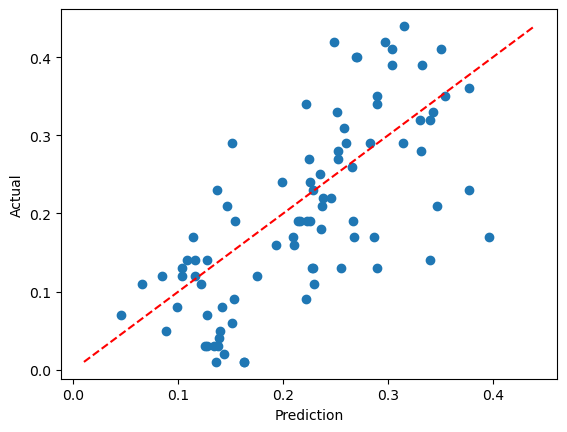

In [158]:
predictor_train, predictor_test, response_train, response_test = train_test_split(
    predictor_vars, response_var,   # ✅ predictors first, response second
    shuffle=True, test_size=0.2, random_state=17)

linear_model = LinearRegression()
linear_model.fit(predictor_train, response_train)

predictions = linear_model.predict(predictor_test)

r2_1 = r2_score(response_test, predictions)
rmse_1 = np.sqrt(mean_squared_error(response_test, predictions))
print("Climate-only model")
print("R2:", r2_1)
print("RMSE:", rmse_1)

plt.scatter(predictions, response_test)
plt.xlabel('Prediction')
plt.ylabel('Actual')
# Add 1:1 line
plt.plot([response_test.min(), response_test.max()], [response_test.min(), response_test.max()], '--', color='red');

---

The R² value is now slightly lower, although still reasonable.

---

<div style="background-color: #CEC2EB; border: 1px solid black; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Bonus materials: cross validation

---
<details>
<summary>💡(click to expand)</summary>

more info here about why we'd use cross validation

</details>    
    
</div>

---

## 4.3 What did the linear model tell us?

The R² value above tells us what proportion of the variation in ERC across catchments 
is explained by our chosen predictors (in this case, around 46%). Take a moment to reflect:

- Is the R² higher or lower than you expected?
- Which variables do you think are doing most of the work?
- What might the model be missing?

Linear regression assumes that each predictor has a **straight-line, additive** 
relationship with ERC — i.e. doubling rainfall doubles the effect on ERC, 
regardless of soil type or topography. 

In reality, catchment behaviour is more complex than this. The effect of rainfall 
on runoff might depend heavily on soil type; steep, impermeable catchments might 
respond very differently to shallow, permeable ones even under the same rainfall. 
These kinds of **interactions and non-linearities** are difficult for a linear 
model to capture.

> 💡 This doesn't mean linear regression is useless — it's interpretable, fast, 
> and often a sensible starting point. But it sets a benchmark we can try to beat.


---

## 4.4 Can we do better? Introducing the Random Forest

To capture more complex relationships, we can turn to a **machine learning** approach 
called a **Random Forest**.

Before we build one, it helps to understand the building block: a **decision tree**.

### Decision trees

A decision tree makes predictions by asking a sequence of yes/no questions about 
the input variables: 

----

![RF_Explained](InputFigures/DecisionTree_Explainer_Image.png)

---

The above example is for classification not regression. In terms of predicting a continuous variable like ERC, it will be similar to the above, but ...:


```
Is mean annual precipitation > 1200 mm?
├── Yes → Is aridity < 0.5?
│         ├── Yes → predict ERC ≈ 0.6
│         └── No  → predict ERC ≈ 0.4
└── No  → Is clay content > 40%?
├── Yes → predict ERC ≈ 0.3
└── No  → predict ERC ≈ 0.2
```

---


Each split is chosen to best separate catchments with high vs low ERC. 
The tree keeps splitting until it reaches a stopping point, then predicts 
the average ERC of all catchments that fall into that final group.

Decision trees are intuitive, but have a major weakness in that they tend to 
**overfit**. This means that they memorise the training data so well that they perform poorly 
on new, unseen catchments.

### From one (decision) tree to a (random) forest

A **Random Forest** fixes this by building **hundreds of trees**, each trained on:
- A **random subset of catchments** (so each tree sees different data)
- A **random subset of predictors** at each split (so trees don't all rely 
  on the same dominant variable)

The final prediction is the **average across all trees**. This averaging process — 
called **ensemble learning** — smooths out the quirks of individual trees and 
produces a much more robust model.

> 💡 Think of it like asking 500 different experts each with slightly different 
> experience, then averaging their answers — more reliable than any single expert.

![RF_Explained](InputFigures/RF_Explainer_Image.png)

### Why does this matter for hydrology?

Random Forests are well-suited to catchment prediction because:
- They handle **non-linear relationships** (e.g. the effect of slope on runoff 
  only matters above a certain threshold)
- They cope well with **correlated predictors** (e.g. rainfall and aridity 
  are related, but a RF can still use both sensibly)
- They produce **feature importance scores** that tell us which variables 
  the model found most useful — giving us hydrological insight, not just a prediction

Image from: https://thaddeus-segura.com/random-forest/


In [ ]:
# # -------------------------
# # 3️⃣ Clean data (remove NaNs and Infs)
# # -------------------------
# data = pd.concat([X, y], axis=1)
# data = data.replace([np.inf, -np.inf], np.nan).dropna()

# X = data[X.columns]
# y = data[y.name]

---

Okay, so let's now fit a random forest model. We'll use the same test and training data as we used for the linear model before. 

Is the performance any better than the linear model?

---

/home/kv25483/anaconda3/envs/futureflood/lib/python3.10/site-packages/sklearn/base.py:1365: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)



Random Forest performance
R²: 0.541
RMSE: 0.079


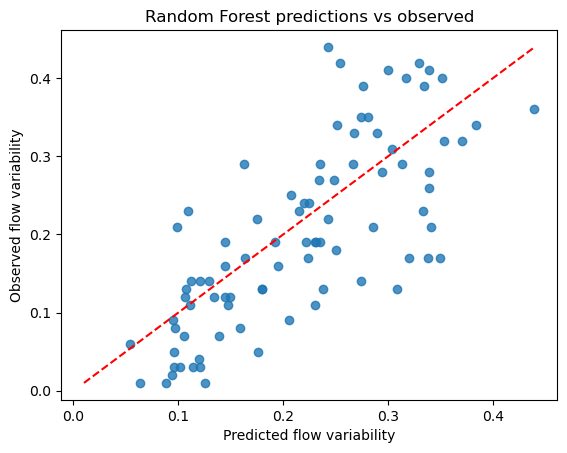

In [160]:
rf_model = RandomForestRegressor(random_state=42)
rf_model.fit(predictor_train, response_train)

pred_rf = rf_model.predict(predictor_test)
r2_rf = r2_score(response_test, pred_rf)
rmse_rf = np.sqrt(mean_squared_error(response_test, pred_rf))

print("\nRandom Forest performance")
print("R²:", round(r2_rf,3))
print("RMSE:", round(rmse_rf,3))

# -------------------------
# 8️⃣ Plot predicted vs observed (Random Forest example)
# -------------------------
plt.scatter(pred_rf, response_test, alpha=0.8)
plt.plot([response_test.min(), response_test.max()], [response_test.min(), response_test.max()], '--', color='red')
plt.xlabel("Predicted flow variability")
plt.ylabel("Observed flow variability")
plt.title("Random Forest predictions vs observed")
plt.show()

---

The preformance is slightly better than for the linear model.  
One other advantage, is we can see which features contributed the most to the predictions

--- 

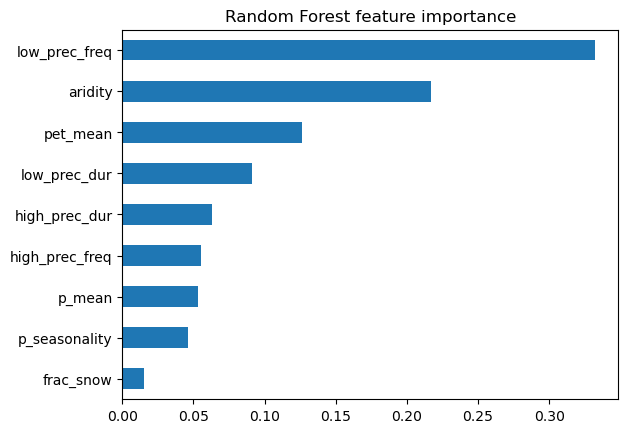

In [162]:
importances = pd.Series(rf_model.feature_importances_, index=predictor_vars.columns)
importances.sort_values().plot.barh()
plt.title("Random Forest feature importance")
plt.show()

---

What do you notice about how these compare to the pairwise correlation table at the beginning?

Correlation measures linear, pairwise relationships

- It looks at each feature vs the target in isolation
- It only captures linear relationships
- It ignores how features interact with each other

Random Forest importance measures contribution within the full model

- It captures non-linear relationships
- It accounts for interactions between features
- A feature's importance reflects how useful it is given all other features are present

---

<div style="background-color: #f0faf0; border: 1px solid #4CAF50; border-radius: 5px; padding: 15px 20px; margin: 10px 0px;">

## Task 4: Coding challenge: can you improve the Random Forest?

So far, our Random Forest has only used **climatic variables** to predict ERC. 
But we know that catchment behaviour is shaped by much more than 
climate alone — soils, topography, geology, and land cover all play a role.

> 💡 **Your challenge:** experiment with different combinations of catchment 
> attributes and see whether you can improve on the climate-only model's performance.

---

### Available datasets

The following attribute tables are already loaded and ready to use:

| Variable | Dataset | Example variables |
|---|---|---|
| 🏔️ **Topography** | `topography` | Slope, elevation, area |
| 🪨 **Hydrogeology** | `hydrogeology` | Baseflow index, permeability |
| 🌱 **Soils** | `soil` | Clay content, soil depth, porosity |
| 🌳 **Land cover** | `landcover` | % woodland, % urban, % grassland |

---

### ➪ Your tasks

1. **Pick one or more** of the datasets above and merge it with the existing 
   predictor variables
2. **Re-run the Random Forest** with the new predictors included
3. **Compare the R² and RMSE** against the climate-only benchmark:

| Model | R² | RMSE |
|---|---|---|
| Climate only (baseline) |0.54 | 0.079 |
| Your improved model | | |

4. **Inspect the feature importance plot** — which new variables did the model 
   find most useful?

---

### 🤔 Think about it

- Does adding more variables always improve performance — or can it sometimes hurt?
- Are there variables that you expected to be important but weren't?
- Does the feature importance ranking match the pairwise correlations from Section 3?

---

<details>
<summary>💡 Hints (click to expand)</summary>

- You can merge additional columns into `predictor_vars` using pandas:
```python
  # Example: adding topographic variables
  topo_columns = ['elev_mean', 'slope_mean', 'area']  # adjust as needed
  new_predictors = catchment_attributes_with_erc[climatic_columns + topo_columns]
```
- Re-run the `train_test_split` with the same `random_state` so results are 
  comparable
- Check for `NaN` values in new columns before fitting — some attributes may 
  have missing data for certain catchments:
```python
  new_predictors.isna().sum()
```

</details>

---

### ⭐ Bonus challenge

Can you find the **single best individual predictor** of ERC across *all* 
available attribute categories? Use the correlation analysis from Section 3 
as a starting point, then test it in a single-variable Random Forest.

<div>